# Worksheet 8: Decision Tree, Ensemble Methods and Hyperparameter Tuning

**Course:** 5CS037 - Concepts and Technologies of AI

This notebook contains solutions for:
- **Task 1:** Implement Classification Models (Decision Tree & Random Forest) using Wine Dataset
- **Task 2:** Hyperparameter Tuning using GridSearchCV for Random Forest Classifier
- **Task 3:** Implement Regression Models with RandomSearchCV tuning

---

## Section 1: Import Required Libraries

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn imports
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    mean_squared_error,
    r2_score
)
from scipy.stats import randint, uniform

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


## Section 2: Load and Explore the Dataset

We will use the **Wine Dataset** from scikit-learn which contains chemical analysis results from wines grown in the same region in Italy but derived from three different cultivars.

In [2]:
# Load the Wine Dataset
wine = load_wine()

# Create a DataFrame for better exploration
df = pd.DataFrame(data=wine.data, columns=wine.feature_names)
df['target'] = wine.target

# Display dataset information
print("="*60)
print("WINE DATASET EXPLORATION")
print("="*60)
print(f"\nDataset Shape: {df.shape}")
print(f"\nFeature Names: {wine.feature_names}")
print(f"\nTarget Names (Wine Classes): {wine.target_names}")
print(f"\nTarget Distribution:\n{df['target'].value_counts().sort_index()}")

# Display first few rows
print("\nFirst 5 rows of the dataset:")
df.head()

WINE DATASET EXPLORATION

Dataset Shape: (178, 14)

Feature Names: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Target Names (Wine Classes): ['class_0' 'class_1' 'class_2']

Target Distribution:
target
0    59
1    71
2    48
Name: count, dtype: int64

First 5 rows of the dataset:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [3]:
# Statistical summary
print("Statistical Summary of Features:")
df.describe()

Statistical Summary of Features:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


## Section 3: Data Preprocessing

Split the data into features (X) and target (y), then create training and testing sets.

In [4]:
# Separate features and target
X = wine.data
y = wine.target

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Data Split Summary:")
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"Number of features: {X_train.shape[1]}")

Data Split Summary:
Training set size: 142 samples
Testing set size: 36 samples
Number of features: 13


---
# TASK 1: Implement Classification Models

Train a **Decision Tree Classifier** and a **Random Forest Classifier** using scikit-learn, then compare the models based on their **F1 scores**.

---

## Section 4: Train a Decision Tree Classifier

In [5]:
# Create and train a Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

# Make predictions
dt_predictions = dt_classifier.predict(X_test)

# Calculate metrics
dt_accuracy = accuracy_score(y_test, dt_predictions)
dt_f1 = f1_score(y_test, dt_predictions, average='weighted')

print("="*60)
print("DECISION TREE CLASSIFIER RESULTS")
print("="*60)
print(f"\nAccuracy: {dt_accuracy:.4f}")
print(f"F1 Score (weighted): {dt_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, dt_predictions, target_names=wine.target_names))

DECISION TREE CLASSIFIER RESULTS

Accuracy: 0.9444
F1 Score (weighted): 0.9450

Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      0.92      0.96        12
     class_1       0.88      1.00      0.93        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.96      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



## Section 5: Visualize the Decision Tree

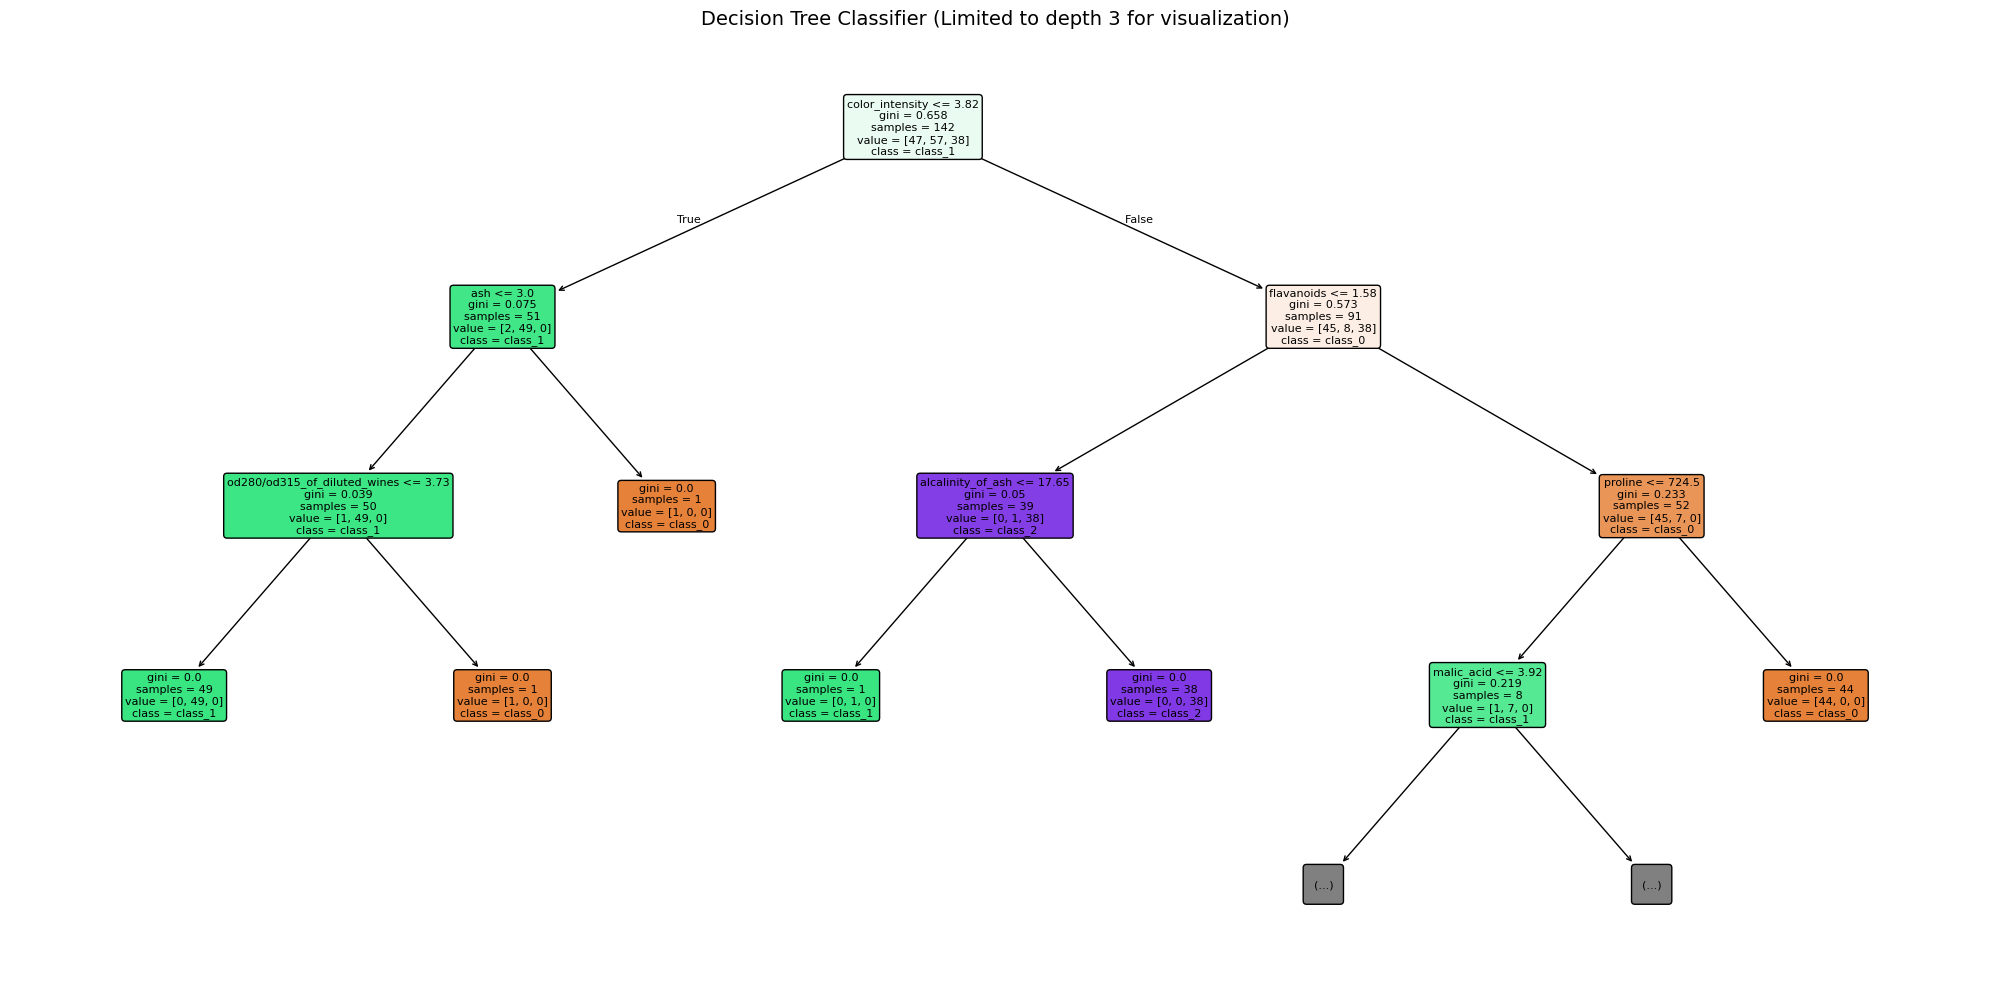

In [6]:
# Visualize the Decision Tree
plt.figure(figsize=(20, 10))
plot_tree(dt_classifier,
          feature_names=wine.feature_names,
          class_names=wine.target_names,
          filled=True,
          rounded=True,
          fontsize=8,
          max_depth=3)  # Limiting depth for better visualization
plt.title("Decision Tree Classifier (Limited to depth 3 for visualization)", fontsize=14)
plt.tight_layout()
plt.show()

## Section 6: Evaluate Decision Tree Performance with Cross-Validation

In [7]:
# Cross-validation for Decision Tree
dt_cv_scores = cross_val_score(dt_classifier, X, y, cv=5, scoring='f1_weighted')

print("Decision Tree - Cross-Validation Results (5-fold):")
print(f"F1 Scores: {dt_cv_scores}")
print(f"Mean F1 Score: {dt_cv_scores.mean():.4f}")
print(f"Standard Deviation: {dt_cv_scores.std():.4f}")

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, dt_predictions))

Decision Tree - Cross-Validation Results (5-fold):
F1 Scores: [0.91446479 0.79793028 0.83636364 0.91514243 0.85240023]
Mean F1 Score: 0.8633
Standard Deviation: 0.0457

Confusion Matrix:
[[11  1  0]
 [ 0 14  0]
 [ 0  1  9]]


## Section 7: Implement Bagging Classifier

In [8]:
# Create and train a Bagging Classifier
bagging_classifier = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)
bagging_classifier.fit(X_train, y_train)

# Make predictions
bagging_predictions = bagging_classifier.predict(X_test)

# Calculate metrics
bagging_accuracy = accuracy_score(y_test, bagging_predictions)
bagging_f1 = f1_score(y_test, bagging_predictions, average='weighted')

print("="*60)
print("BAGGING CLASSIFIER RESULTS")
print("="*60)
print(f"\nAccuracy: {bagging_accuracy:.4f}")
print(f"F1 Score (weighted): {bagging_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, bagging_predictions, target_names=wine.target_names))

BAGGING CLASSIFIER RESULTS

Accuracy: 1.0000
F1 Score (weighted): 1.0000

Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



## Section 8: Implement Random Forest Classifier

In [9]:
# Create and train a Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

# Make predictions
rf_predictions = rf_classifier.predict(X_test)

# Calculate metrics
rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions, average='weighted')

print("="*60)
print("RANDOM FOREST CLASSIFIER RESULTS")
print("="*60)
print(f"\nAccuracy: {rf_accuracy:.4f}")
print(f"F1 Score (weighted): {rf_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_predictions, target_names=wine.target_names))

RANDOM FOREST CLASSIFIER RESULTS

Accuracy: 1.0000
F1 Score (weighted): 1.0000

Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



Feature Importance (Random Forest):
                         feature  importance
9                color_intensity    0.187580
6                     flavanoids    0.159561
12                       proline    0.146799
0                        alcohol    0.117913
10                           hue    0.101538
11  od280/od315_of_diluted_wines    0.096301
5                  total_phenols    0.041514
4                      magnesium    0.040131
1                     malic_acid    0.033894
3              alcalinity_of_ash    0.025471
8                proanthocyanins    0.023530
2                            ash    0.018157
7           nonflavanoid_phenols    0.007610


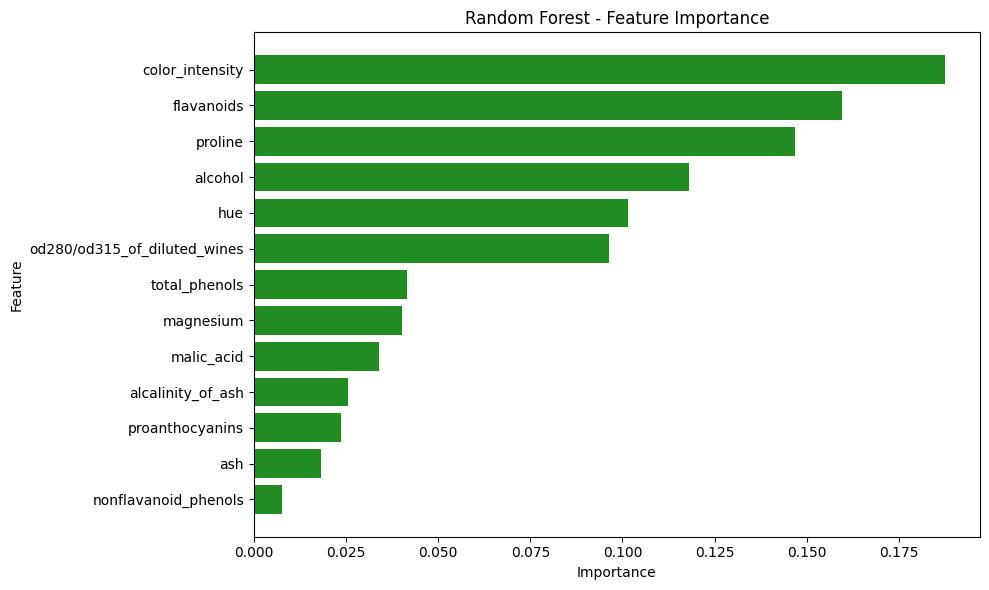

In [10]:
# Feature Importance from Random Forest
feature_importance = pd.DataFrame({
    'feature': wine.feature_names,
    'importance': rf_classifier.feature_importances_
}).sort_values('importance', ascending=False)

print("Feature Importance (Random Forest):")
print(feature_importance)

# Visualize feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'], color='forestgreen')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Random Forest - Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Section 9: Implement AdaBoost Classifier

In [11]:
# Create and train an AdaBoost Classifier
adaboost_classifier = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    random_state=42,
    algorithm='SAMME'
)
adaboost_classifier.fit(X_train, y_train)

# Make predictions
adaboost_predictions = adaboost_classifier.predict(X_test)

# Calculate metrics
adaboost_accuracy = accuracy_score(y_test, adaboost_predictions)
adaboost_f1 = f1_score(y_test, adaboost_predictions, average='weighted')

print("="*60)
print("ADABOOST CLASSIFIER RESULTS")
print("="*60)
print(f"\nAccuracy: {adaboost_accuracy:.4f}")
print(f"F1 Score (weighted): {adaboost_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, adaboost_predictions, target_names=wine.target_names))

ADABOOST CLASSIFIER RESULTS

Accuracy: 0.9167
F1 Score (weighted): 0.9165

Classification Report:
              precision    recall  f1-score   support

     class_0       0.86      1.00      0.92        12
     class_1       0.92      0.86      0.89        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.92        36
   macro avg       0.93      0.92      0.92        36
weighted avg       0.92      0.92      0.92        36



## Section 10: Implement Gradient Boosting Classifier

In [12]:
# Create and train a Gradient Boosting Classifier
gb_classifier = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_classifier.fit(X_train, y_train)

# Make predictions
gb_predictions = gb_classifier.predict(X_test)

# Calculate metrics
gb_accuracy = accuracy_score(y_test, gb_predictions)
gb_f1 = f1_score(y_test, gb_predictions, average='weighted')

print("="*60)
print("GRADIENT BOOSTING CLASSIFIER RESULTS")
print("="*60)
print(f"\nAccuracy: {gb_accuracy:.4f}")
print(f"F1 Score (weighted): {gb_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, gb_predictions, target_names=wine.target_names))

GRADIENT BOOSTING CLASSIFIER RESULTS

Accuracy: 0.9444
F1 Score (weighted): 0.9443

Classification Report:
              precision    recall  f1-score   support

     class_0       0.92      1.00      0.96        12
     class_1       0.93      0.93      0.93        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.95      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



## Section 11: Compare Ensemble Methods Performance

### Task 1 Completion: Comparison of Decision Tree vs Random Forest (F1 Scores)

In [13]:
# Create comparison summary
results = {
    'Model': ['Decision Tree', 'Bagging', 'Random Forest', 'AdaBoost', 'Gradient Boosting'],
    'Accuracy': [dt_accuracy, bagging_accuracy, rf_accuracy, adaboost_accuracy, gb_accuracy],
    'F1 Score': [dt_f1, bagging_f1, rf_f1, adaboost_f1, gb_f1]
}

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('F1 Score', ascending=False).reset_index(drop=True)

print("="*60)
print("MODEL COMPARISON - CLASSIFICATION (TASK 1 RESULTS)")
print("="*60)
print("\nAll Models Performance Summary:")
print(results_df.to_string(index=False))

print("\n" + "="*60)
print("TASK 1 ANSWER: Decision Tree vs Random Forest Comparison")
print("="*60)
print(f"\nDecision Tree F1 Score: {dt_f1:.4f}")
print(f"Random Forest F1 Score: {rf_f1:.4f}")
print(f"\nDifference: {(rf_f1 - dt_f1):.4f}")
if rf_f1 > dt_f1:
    print("Conclusion: Random Forest outperforms Decision Tree!")
else:
    print("Conclusion: Decision Tree performs better or equal to Random Forest!")

MODEL COMPARISON - CLASSIFICATION (TASK 1 RESULTS)

All Models Performance Summary:
            Model  Accuracy  F1 Score
          Bagging  1.000000  1.000000
    Random Forest  1.000000  1.000000
    Decision Tree  0.944444  0.944961
Gradient Boosting  0.944444  0.944269
         AdaBoost  0.916667  0.916529

TASK 1 ANSWER: Decision Tree vs Random Forest Comparison

Decision Tree F1 Score: 0.9450
Random Forest F1 Score: 1.0000

Difference: 0.0550
Conclusion: Random Forest outperforms Decision Tree!


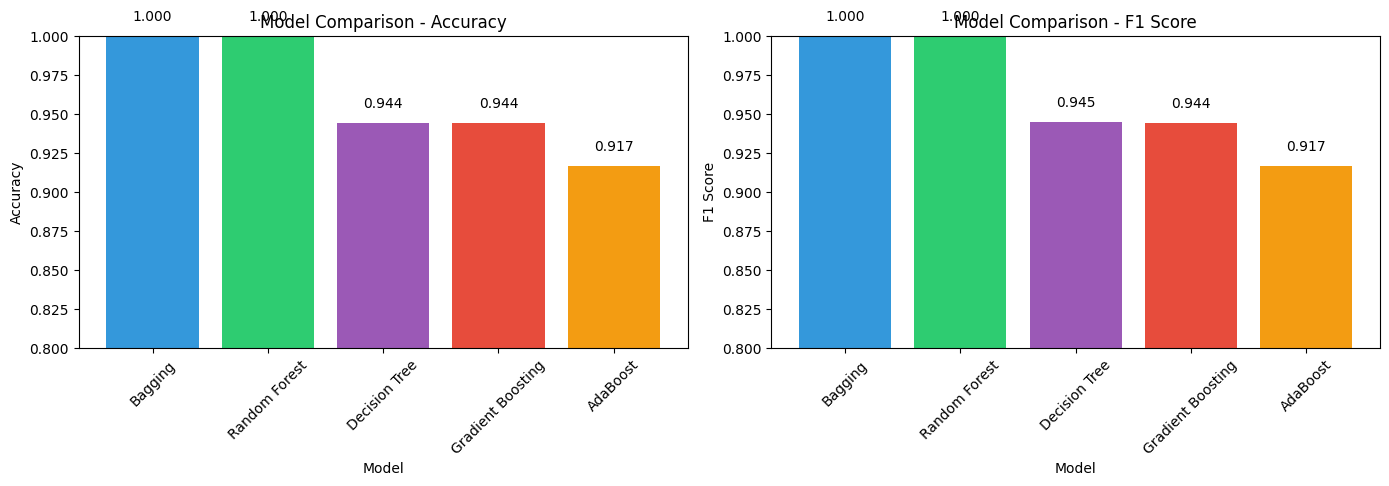

In [14]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
colors = ['#3498db', '#2ecc71', '#9b59b6', '#e74c3c', '#f39c12']
axes[0].bar(results_df['Model'], results_df['Accuracy'], color=colors)
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Comparison - Accuracy')
axes[0].set_ylim(0.8, 1.0)
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(results_df['Accuracy']):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10)

# F1 Score comparison
axes[1].bar(results_df['Model'], results_df['F1 Score'], color=colors)
axes[1].set_xlabel('Model')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('Model Comparison - F1 Score')
axes[1].set_ylim(0.8, 1.0)
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(results_df['F1 Score']):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

---
# TASK 2: Hyperparameter Tuning with GridSearchCV

**Objective:** Identify three hyperparameters of Random Forest Classifier and perform hyperparameter tuning using GridSearchCV.

**Selected Hyperparameters:**
1. `n_estimators` - Number of trees in the forest
2. `max_depth` - Maximum depth of the trees
3. `min_samples_split` - Minimum samples required to split an internal node

---

## Section 12: Hyperparameter Tuning with GridSearchCV

In [15]:
# Define the parameter grid for GridSearchCV
# Three hyperparameters as required by Task 2

param_grid = {
    'n_estimators': [50, 100, 150, 200],      # Number of trees
    'max_depth': [None, 5, 10, 15, 20],       # Maximum depth of trees
    'min_samples_split': [2, 5, 10]           # Minimum samples to split
}

print("="*60)
print("TASK 2: HYPERPARAMETER TUNING WITH GRIDSEARCHCV")
print("="*60)
print("\nThree Hyperparameters Selected for Tuning:")
print("1. n_estimators: Number of trees in the forest")
print("   Values to test:", param_grid['n_estimators'])
print("\n2. max_depth: Maximum depth of each tree")
print("   Values to test:", param_grid['max_depth'])
print("\n3. min_samples_split: Minimum samples required to split a node")
print("   Values to test:", param_grid['min_samples_split'])

total_combinations = len(param_grid['n_estimators']) * len(param_grid['max_depth']) * len(param_grid['min_samples_split'])
print(f"\nTotal parameter combinations to test: {total_combinations}")

TASK 2: HYPERPARAMETER TUNING WITH GRIDSEARCHCV

Three Hyperparameters Selected for Tuning:
1. n_estimators: Number of trees in the forest
   Values to test: [50, 100, 150, 200]

2. max_depth: Maximum depth of each tree
   Values to test: [None, 5, 10, 15, 20]

3. min_samples_split: Minimum samples required to split a node
   Values to test: [2, 5, 10]

Total parameter combinations to test: 60


In [16]:
# Perform GridSearchCV
rf_grid = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf_grid,
    param_grid=param_grid,
    cv=5,                    # 5-fold cross-validation
    scoring='f1_weighted',   # Optimize for F1 score
    n_jobs=-1,               # Use all CPU cores
    verbose=1
)

print("Running GridSearchCV...")
grid_search.fit(X_train, y_train)

print("\n" + "="*60)
print("GRIDSEARCHCV RESULTS")
print("="*60)
print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation F1 Score: {grid_search.best_score_:.4f}")

Running GridSearchCV...
Fitting 5 folds for each of 60 candidates, totalling 300 fits

GRIDSEARCHCV RESULTS

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Best Cross-Validation F1 Score: 0.9860


In [17]:
# Display top 10 parameter combinations
cv_results = pd.DataFrame(grid_search.cv_results_)
top_results = cv_results[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
top_results = top_results.sort_values('rank_test_score').head(10)

print("\nTop 10 Parameter Combinations:")
for idx, row in top_results.iterrows():
    print(f"Rank {row['rank_test_score']}: F1={row['mean_test_score']:.4f} (±{row['std_test_score']:.4f}) - {row['params']}")


Top 10 Parameter Combinations:
Rank 1: F1=0.9860 (±0.0281) - {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Rank 1: F1=0.9860 (±0.0281) - {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Rank 1: F1=0.9860 (±0.0281) - {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 150}
Rank 1: F1=0.9860 (±0.0281) - {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Rank 1: F1=0.9860 (±0.0281) - {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}
Rank 1: F1=0.9860 (±0.0281) - {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 150}
Rank 1: F1=0.9860 (±0.0281) - {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 100}
Rank 1: F1=0.9860 (±0.0281) - {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 50}
Rank 1: F1=0.9860 (±0.0281) - {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 150}
Rank 1: F1=0.9860 (±0.0281) - {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}


## Section 13: Evaluate Tuned Model (GridSearchCV)

In [18]:
# Evaluate the best model on test set
best_rf_classifier = grid_search.best_estimator_
best_rf_predictions = best_rf_classifier.predict(X_test)

# Calculate metrics
best_rf_accuracy = accuracy_score(y_test, best_rf_predictions)
best_rf_f1 = f1_score(y_test, best_rf_predictions, average='weighted')

print("="*60)
print("TUNED RANDOM FOREST CLASSIFIER (GridSearchCV) RESULTS")
print("="*60)
print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"\nTest Set Performance:")
print(f"Accuracy: {best_rf_accuracy:.4f}")
print(f"F1 Score (weighted): {best_rf_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, best_rf_predictions, target_names=wine.target_names))

# Compare with baseline
print("\n" + "="*60)
print("IMPROVEMENT ANALYSIS")
print("="*60)
print(f"Baseline Random Forest F1: {rf_f1:.4f}")
print(f"Tuned Random Forest F1: {best_rf_f1:.4f}")
print(f"Improvement: {((best_rf_f1 - rf_f1) / rf_f1 * 100):.2f}%")

TUNED RANDOM FOREST CLASSIFIER (GridSearchCV) RESULTS

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}

Test Set Performance:
Accuracy: 1.0000
F1 Score (weighted): 1.0000

Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36


IMPROVEMENT ANALYSIS
Baseline Random Forest F1: 1.0000
Tuned Random Forest F1: 1.0000
Improvement: 0.00%


---
# TASK 3: Implement Regression Models

**Objective:**
- Train a Decision Tree Regressor and Random Forest Regressor using scikit-learn
- Identify three parameters for Random Forest Regressor
- Perform hyperparameter tuning using RandomSearchCV

For regression, we'll use the Wine dataset with a continuous target (alcohol content prediction from other features).

---

## Section 14: Prepare Data for Regression

For regression tasks, we'll predict `alcohol` content using other wine features.

In [19]:
# For regression, we'll predict 'alcohol' (first feature) using other features
# Create regression dataset from wine data

# Reload wine data for regression
wine_data = load_wine()
df_reg = pd.DataFrame(data=wine_data.data, columns=wine_data.feature_names)

# Target: 'alcohol' (first column)
# Features: all other columns
X_reg = df_reg.drop('alcohol', axis=1)  # Features (excluding alcohol)
y_reg = df_reg['alcohol']                # Target (alcohol content)

# Split for regression
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print("="*60)
print("REGRESSION DATA PREPARATION")
print("="*60)
print(f"\nTarget Variable: alcohol content")
print(f"Number of Features: {X_reg.shape[1]}")
print(f"Training samples: {X_train_reg.shape[0]}")
print(f"Testing samples: {X_test_reg.shape[0]}")
print(f"\nTarget Statistics:")
print(f"  Mean: {y_reg.mean():.2f}")
print(f"  Std: {y_reg.std():.2f}")
print(f"  Min: {y_reg.min():.2f}")
print(f"  Max: {y_reg.max():.2f}")

REGRESSION DATA PREPARATION

Target Variable: alcohol content
Number of Features: 12
Training samples: 142
Testing samples: 36

Target Statistics:
  Mean: 13.00
  Std: 0.81
  Min: 11.03
  Max: 14.83


## Section 15: Train Decision Tree Regressor

In [20]:
# Create and train Decision Tree Regressor
dt_regressor = DecisionTreeRegressor(random_state=42)
dt_regressor.fit(X_train_reg, y_train_reg)

# Make predictions
dt_reg_predictions = dt_regressor.predict(X_test_reg)

# Calculate metrics
dt_reg_mse = mean_squared_error(y_test_reg, dt_reg_predictions)
dt_reg_rmse = np.sqrt(dt_reg_mse)
dt_reg_r2 = r2_score(y_test_reg, dt_reg_predictions)

print("="*60)
print("DECISION TREE REGRESSOR RESULTS")
print("="*60)
print(f"\nMean Squared Error (MSE): {dt_reg_mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {dt_reg_rmse:.4f}")
print(f"R² Score: {dt_reg_r2:.4f}")

DECISION TREE REGRESSOR RESULTS

Mean Squared Error (MSE): 0.3120
Root Mean Squared Error (RMSE): 0.5585
R² Score: 0.4775


## Section 16: Train Random Forest Regressor

In [21]:
# Create and train Random Forest Regressor
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor.fit(X_train_reg, y_train_reg)

# Make predictions
rf_reg_predictions = rf_regressor.predict(X_test_reg)

# Calculate metrics
rf_reg_mse = mean_squared_error(y_test_reg, rf_reg_predictions)
rf_reg_rmse = np.sqrt(rf_reg_mse)
rf_reg_r2 = r2_score(y_test_reg, rf_reg_predictions)

print("="*60)
print("RANDOM FOREST REGRESSOR RESULTS")
print("="*60)
print(f"\nMean Squared Error (MSE): {rf_reg_mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rf_reg_rmse:.4f}")
print(f"R² Score: {rf_reg_r2:.4f}")

RANDOM FOREST REGRESSOR RESULTS

Mean Squared Error (MSE): 0.1543
Root Mean Squared Error (RMSE): 0.3928
R² Score: 0.7416


## Section 17: Hyperparameter Tuning with RandomizedSearchCV

**Three Parameters for Random Forest Regressor:**
1. `n_estimators` - Number of trees in the forest
2. `max_depth` - Maximum depth of each tree
3. `min_samples_leaf` - Minimum samples required at a leaf node

In [22]:
# Define parameter distributions for RandomizedSearchCV
# Three hyperparameters as required by Task 3

param_distributions = {
    'n_estimators': randint(50, 300),          # Random integers between 50 and 300
    'max_depth': [None, 5, 10, 15, 20, 25, 30], # Maximum depth options
    'min_samples_leaf': randint(1, 10)          # Random integers between 1 and 10
}

print("="*60)
print("TASK 3: HYPERPARAMETER TUNING WITH RANDOMIZEDSEARCHCV")
print("="*60)
print("\nThree Parameters Selected for Tuning:")
print("1. n_estimators: Number of trees in the forest")
print("   Distribution: Uniform random integer between 50 and 300")
print("\n2. max_depth: Maximum depth of each tree")
print("   Values:", param_distributions['max_depth'])
print("\n3. min_samples_leaf: Minimum samples required at leaf node")
print("   Distribution: Uniform random integer between 1 and 10")

TASK 3: HYPERPARAMETER TUNING WITH RANDOMIZEDSEARCHCV

Three Parameters Selected for Tuning:
1. n_estimators: Number of trees in the forest
   Distribution: Uniform random integer between 50 and 300

2. max_depth: Maximum depth of each tree
   Values: [None, 5, 10, 15, 20, 25, 30]

3. min_samples_leaf: Minimum samples required at leaf node
   Distribution: Uniform random integer between 1 and 10


In [23]:
# Perform RandomizedSearchCV
rf_random = RandomForestRegressor(random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf_random,
    param_distributions=param_distributions,
    n_iter=50,              # Number of parameter combinations to try
    cv=5,                   # 5-fold cross-validation
    scoring='r2',           # Optimize for R² score
    n_jobs=-1,              # Use all CPU cores
    random_state=42,
    verbose=1
)

print("Running RandomizedSearchCV with 50 iterations...")
random_search.fit(X_train_reg, y_train_reg)

print("\n" + "="*60)
print("RANDOMIZEDSEARCHCV RESULTS")
print("="*60)
print(f"\nBest Parameters: {random_search.best_params_}")
print(f"Best Cross-Validation R² Score: {random_search.best_score_:.4f}")

Running RandomizedSearchCV with 50 iterations...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

RANDOMIZEDSEARCHCV RESULTS

Best Parameters: {'max_depth': 30, 'min_samples_leaf': 9, 'n_estimators': 256}
Best Cross-Validation R² Score: 0.5181


## Section 18: Evaluate Tuned Regressor Model (RandomizedSearchCV)

In [24]:
# Evaluate the best regressor model on test set
best_rf_regressor = random_search.best_estimator_
best_rf_reg_predictions = best_rf_regressor.predict(X_test_reg)

# Calculate metrics
best_rf_reg_mse = mean_squared_error(y_test_reg, best_rf_reg_predictions)
best_rf_reg_rmse = np.sqrt(best_rf_reg_mse)
best_rf_reg_r2 = r2_score(y_test_reg, best_rf_reg_predictions)

print("="*60)
print("TUNED RANDOM FOREST REGRESSOR (RandomizedSearchCV) RESULTS")
print("="*60)
print(f"\nBest Parameters: {random_search.best_params_}")
print(f"\nTest Set Performance:")
print(f"Mean Squared Error (MSE): {best_rf_reg_mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {best_rf_reg_rmse:.4f}")
print(f"R² Score: {best_rf_reg_r2:.4f}")

# Compare with baseline
print("\n" + "="*60)
print("IMPROVEMENT ANALYSIS (REGRESSION)")
print("="*60)
print(f"Decision Tree R²: {dt_reg_r2:.4f}")
print(f"Baseline Random Forest R²: {rf_reg_r2:.4f}")
print(f"Tuned Random Forest R²: {best_rf_reg_r2:.4f}")
print(f"\nImprovement over baseline: {((best_rf_reg_r2 - rf_reg_r2) / rf_reg_r2 * 100):.2f}%")

TUNED RANDOM FOREST REGRESSOR (RandomizedSearchCV) RESULTS

Best Parameters: {'max_depth': 30, 'min_samples_leaf': 9, 'n_estimators': 256}

Test Set Performance:
Mean Squared Error (MSE): 0.1454
Root Mean Squared Error (RMSE): 0.3814
R² Score: 0.7564

IMPROVEMENT ANALYSIS (REGRESSION)
Decision Tree R²: 0.4775
Baseline Random Forest R²: 0.7416
Tuned Random Forest R²: 0.7564

Improvement over baseline: 1.99%


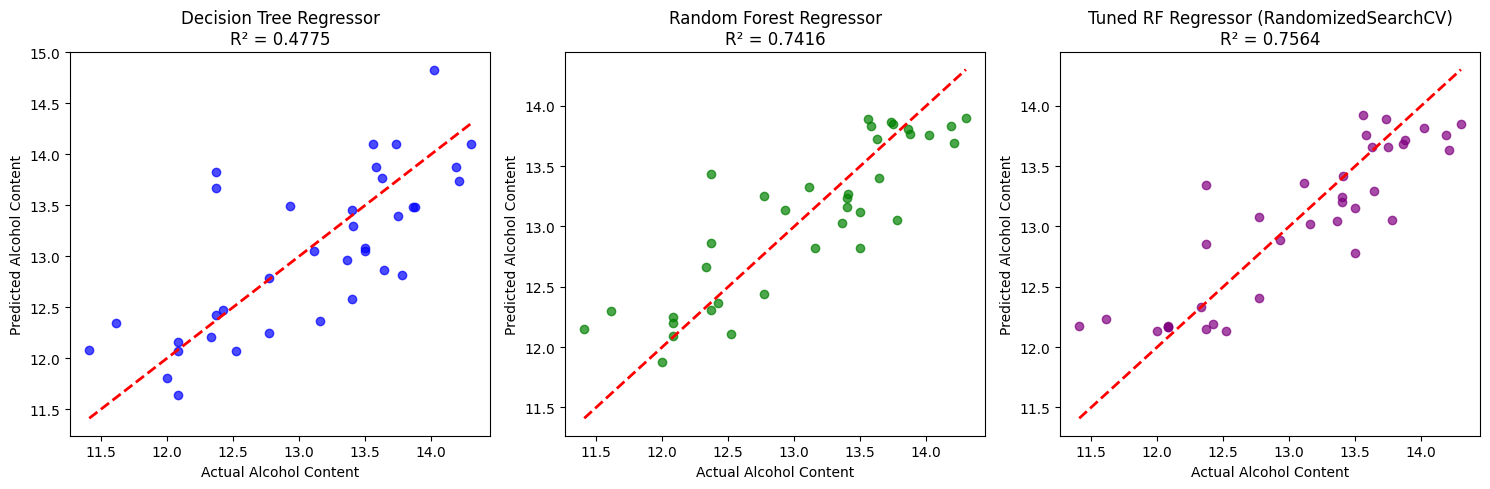

In [25]:
# Visualize Regression Results: Actual vs Predicted
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Decision Tree predictions
axes[0].scatter(y_test_reg, dt_reg_predictions, alpha=0.7, color='blue')
axes[0].plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Alcohol Content')
axes[0].set_ylabel('Predicted Alcohol Content')
axes[0].set_title(f'Decision Tree Regressor\nR² = {dt_reg_r2:.4f}')

# Baseline Random Forest predictions
axes[1].scatter(y_test_reg, rf_reg_predictions, alpha=0.7, color='green')
axes[1].plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Alcohol Content')
axes[1].set_ylabel('Predicted Alcohol Content')
axes[1].set_title(f'Random Forest Regressor\nR² = {rf_reg_r2:.4f}')

# Tuned Random Forest predictions
axes[2].scatter(y_test_reg, best_rf_reg_predictions, alpha=0.7, color='purple')
axes[2].plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
axes[2].set_xlabel('Actual Alcohol Content')
axes[2].set_ylabel('Predicted Alcohol Content')
axes[2].set_title(f'Tuned RF Regressor (RandomizedSearchCV)\nR² = {best_rf_reg_r2:.4f}')

plt.tight_layout()
plt.show()

---
# Summary and Conclusions

## Task Summary

In [26]:
# Final Summary
print("="*70)
print("                    WORKSHEET 8 - FINAL SUMMARY")
print("="*70)

print("\n" + "-"*70)
print("TASK 1: Classification Models Comparison (Wine Dataset)")
print("-"*70)
print(f"Decision Tree Classifier F1 Score:     {dt_f1:.4f}")
print(f"Random Forest Classifier F1 Score:     {rf_f1:.4f}")
print(f"Best Performer: {'Random Forest' if rf_f1 > dt_f1 else 'Decision Tree'}")

print("\n" + "-"*70)
print("TASK 2: GridSearchCV Hyperparameter Tuning (Classification)")
print("-"*70)
print("Three hyperparameters tuned:")
print("  1. n_estimators (Number of trees)")
print("  2. max_depth (Maximum tree depth)")
print("  3. min_samples_split (Minimum samples to split)")
print(f"\nBest Parameters Found: {grid_search.best_params_}")
print(f"Tuned Model F1 Score: {best_rf_f1:.4f}")

print("\n" + "-"*70)
print("TASK 3: Regression Models with RandomizedSearchCV (Wine Dataset)")
print("-"*70)
print(f"Decision Tree Regressor R² Score:      {dt_reg_r2:.4f}")
print(f"Random Forest Regressor R² Score:      {rf_reg_r2:.4f}")
print("\nThree parameters tuned with RandomizedSearchCV:")
print("  1. n_estimators (Number of trees)")
print("  2. max_depth (Maximum tree depth)")
print("  3. min_samples_leaf (Minimum samples at leaf)")
print(f"\nBest Parameters Found: {random_search.best_params_}")
print(f"Tuned RF Regressor R² Score: {best_rf_reg_r2:.4f}")

print("\n" + "="*70)
print("                    ALL TASKS COMPLETED SUCCESSFULLY!")
print("="*70)

                    WORKSHEET 8 - FINAL SUMMARY

----------------------------------------------------------------------
TASK 1: Classification Models Comparison (Wine Dataset)
----------------------------------------------------------------------
Decision Tree Classifier F1 Score:     0.9450
Random Forest Classifier F1 Score:     1.0000
Best Performer: Random Forest

----------------------------------------------------------------------
TASK 2: GridSearchCV Hyperparameter Tuning (Classification)
----------------------------------------------------------------------
Three hyperparameters tuned:
  1. n_estimators (Number of trees)
  2. max_depth (Maximum tree depth)
  3. min_samples_split (Minimum samples to split)

Best Parameters Found: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Tuned Model F1 Score: 1.0000

----------------------------------------------------------------------
TASK 3: Regression Models with RandomizedSearchCV (Wine Dataset)
-----------------------